In [1]:
# # If running in Colab / fresh environment:
# !pip install -q silero-vad torchaudio soundfile librosa matplotlib pandas numpy

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import librosa

import torch
import torchaudio
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps

torch.set_num_threads(1)

In [3]:
import os
def get_safe_start_dirs() -> list[Path]:
    """Return possible project locations even if the kernel cwd was deleted."""
    starts = []

    try:
        starts.append(Path.cwd().resolve())
    except FileNotFoundError:
        print("Current working directory no longer exists; trying known project locations.")

    for value in (os.environ.get("PWD"), os.environ.get("OLDPWD")):
        if value:
            starts.append(Path(value).expanduser())

    starts.extend(
        [
            Path("/teamspace/studios/this_studio"),
            Path("/teamspace/studios/this_studio/approaches"),
            Path("/teamspace"),
            Path.home(),
            Path("/content"),
        ]
    )

    unique_starts = []
    seen = set()
    for start in starts:
        try:
            resolved = start.resolve()
        except FileNotFoundError:
            continue
        if resolved in seen:
            continue
        seen.add(resolved)
        unique_starts.append(resolved)
    return unique_starts


def find_project_root(start: Path | None = None) -> Path:
    starts = [start.resolve()] if start is not None else get_safe_start_dirs()

    checked = []
    for start_dir in starts:
        for candidate in [start_dir, *start_dir.parents]:
            checked.append(str(candidate))
            has_audio = (candidate / "audio").exists()
            has_repo_marker = (candidate / "ground_truth.json").exists() or (candidate / "approaches").exists() or (candidate / "context.md").exists()
            if has_audio and has_repo_marker:
                return candidate
            # If the notebook is launched from inside approaches/, the parent is the project root.
            if candidate.name == "approaches" and (candidate.parent / "audio").exists():
                return candidate.parent

    raise FileNotFoundError(
        "Could not find project root. Expected a folder containing audio/ and ground_truth.json or approaches/. "
        f"Checked: {checked}"
    )


PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "approaches" / "approach_1_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "audio_dir": PROJECT_ROOT / "audio",
    "output_dir": OUTPUT_DIR,
    "target_sr": 16000,
    "threshold": 0.5,
    "min_speech_duration_ms": 250,
    "max_speech_duration_s": float("inf"),
    "min_silence_duration_ms": 400,
    "speech_pad_ms": 200,
    "merge_gap_s": 1.0,
    "min_region_s": 1.5,
    "conversation_gap_s": 5.0,
    "plot_width": 18,
    "plot_height": 4,
}

audio_files = sorted(CONFIG["audio_dir"].glob("*.mp3"))

import sys
sys.path.append(str(PROJECT_ROOT / "approaches"))
from output_utils import load_ground_truth, export_uniform_outputs, export_combined_outputs

GROUND_TRUTH = load_ground_truth(PROJECT_ROOT)
print("Audio dir:", CONFIG["audio_dir"])
print("Audio files:", [path.name for path in audio_files])
print("Outputs:", OUTPUT_DIR)


Audio dir: /teamspace/studios/this_studio/audio
Audio files: ['Sample1KN.mp3', 'Sample2EN.mp3', 'sample3KN.mp3']
Outputs: /teamspace/studios/this_studio/approaches/approach_1_outputs


In [4]:
def format_time(seconds: float) -> str:
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:02d}:{secs:06.3f}"


def load_audio_mono_resampled(path: str, target_sr: int = 16000):
    """
    Load audio as mono 16 kHz.

    Lightning/Linux environments often have torchaudio installed without MP3 codec support.
    Use librosa/audioread first because it is more reliable for MP3 files, and keep
    torchaudio as a fallback for environments where it works.
    """
    try:
        audio, sr = librosa.load(path, sr=target_sr, mono=True)
        waveform = torch.from_numpy(audio).float().contiguous()
        return waveform, target_sr
    except Exception as librosa_error:
        print(f"librosa failed to load {path}: {librosa_error}. Falling back to torchaudio.")

    try:
        waveform, sr = torchaudio.load(path)
    except Exception as torchaudio_error:
        raise RuntimeError(
            f"Could not load audio file {path}. Install ffmpeg/libsndfile support or use librosa/audioread-compatible audio decoding."
        ) from torchaudio_error

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        waveform = resampler(waveform)
        sr = target_sr

    waveform = waveform.squeeze(0).contiguous()
    return waveform, sr


def run_silero_vad_on_tensor(waveform: torch.Tensor, sr: int, cfg: dict):
    """
    Run Silero VAD and return speech segments in seconds.
    """
    model = load_silero_vad()

    speech = get_speech_timestamps(
        waveform,
        model,
        sampling_rate=sr,
        threshold=cfg["threshold"],
        min_speech_duration_ms=cfg["min_speech_duration_ms"],
        max_speech_duration_s=cfg["max_speech_duration_s"],
        min_silence_duration_ms=cfg["min_silence_duration_ms"],
        speech_pad_ms=cfg["speech_pad_ms"],
        return_seconds=True,
    )

    # Normalize schema to a simple list
    segments = []
    for seg in speech:
        segments.append({
            "start": float(seg["start"]),
            "end": float(seg["end"]),
            "duration": float(seg["end"] - seg["start"]),
        })
    return segments


def merge_close_segments(segments, merge_gap_s=1.0, min_region_s=1.5):
    """
    Merge segments if the gap between them is small.
    """
    if not segments:
        return []

    segments = sorted(segments, key=lambda x: x["start"])
    merged = [segments[0].copy()]

    for seg in segments[1:]:
        last = merged[-1]
        gap = seg["start"] - last["end"]

        if gap <= merge_gap_s:
            last["end"] = max(last["end"], seg["end"])
            last["duration"] = last["end"] - last["start"]
        else:
            merged.append(seg.copy())

    # Filter tiny merged regions
    merged = [m for m in merged if (m["end"] - m["start"]) >= min_region_s]

    # add ids
    for i, seg in enumerate(merged, start=1):
        seg["region_id"] = i
        seg["duration"] = seg["end"] - seg["start"]

    return merged


def assign_conversation_ids(merged_regions, conversation_gap_s=5.0):
    """
    Group merged speech regions into larger conversation candidates.
    If the gap between merged regions is large, start a new conversation group.
    """
    if not merged_regions:
        return []

    merged_regions = sorted(merged_regions, key=lambda x: x["start"])

    conv_id = 1
    merged_regions[0]["conversation_id"] = conv_id

    for i in range(1, len(merged_regions)):
        prev = merged_regions[i - 1]
        curr = merged_regions[i]
        gap = curr["start"] - prev["end"]

        if gap >= conversation_gap_s:
            conv_id += 1

        curr["conversation_id"] = conv_id

    return merged_regions


def collapse_conversation_groups(regions):
    """
    Convert region-level rows into conversation-level start/end windows.
    """
    if not regions:
        return []

    df = pd.DataFrame(regions)
    grouped = (
        df.groupby("conversation_id", as_index=False)
          .agg(
              start=("start", "min"),
              end=("end", "max"),
              n_regions=("region_id", "count"),
          )
    )
    grouped["duration"] = grouped["end"] - grouped["start"]
    return grouped.to_dict(orient="records")

In [5]:
def plot_waveform_with_segments(waveform, sr, segments, title="Waveform with VAD segments"):
    times = np.arange(len(waveform)) / sr

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.6)
    
    for seg in segments:
        plt.axvspan(seg["start"], seg["end"], alpha=0.25)

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


def plot_waveform_with_conversations(waveform, sr, convs, title="Waveform with conversation candidates"):
    times = np.arange(len(waveform)) / sr

    plt.figure(figsize=(CONFIG["plot_width"], CONFIG["plot_height"]))
    plt.plot(times, waveform.numpy(), linewidth=0.6)

    for conv in convs:
        plt.axvspan(conv["start"], conv["end"], alpha=0.25)
        plt.text(
            conv["start"],
            0.8 * float(waveform.abs().max()),
            f"Conv {int(conv['conversation_id'])}",
            fontsize=10
        )

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

In [6]:
def process_audio_file(audio_path: str, cfg: dict):
    waveform, sr = load_audio_mono_resampled(audio_path, target_sr=cfg["target_sr"])

    speech_segments = run_silero_vad_on_tensor(waveform, sr, cfg)
    merged_regions = merge_close_segments(
        speech_segments,
        merge_gap_s=cfg["merge_gap_s"],
        min_region_s=cfg["min_region_s"],
    )
    region_rows = assign_conversation_ids(
        merged_regions,
        conversation_gap_s=cfg["conversation_gap_s"],
    )
    conversation_rows = collapse_conversation_groups(region_rows)

    # add readable times
    for row in speech_segments:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])

    for row in region_rows:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])

    for row in conversation_rows:
        row["start_hms"] = format_time(row["start"])
        row["end_hms"] = format_time(row["end"])

    return {
        "audio_path": str(audio_path),
        "audio_name": Path(audio_path).name,
        "sample_rate": sr,
        "duration_s": len(waveform) / sr,
        "waveform": waveform,
        "speech_segments": speech_segments,
        "merged_regions": region_rows,
        "conversation_candidates": conversation_rows,
    }

def export_result_tables(result: dict, output_dir: Path):
    return export_uniform_outputs(
        output_dir=output_dir,
        audio_name=result["audio_name"],
        approach_name="approach_1_baseline",
        conversation_candidates=pd.DataFrame(result["conversation_candidates"]),
        final_two=pd.DataFrame(result.get("final_two_conversations", [])),
        ground_truth=GROUND_TRUTH,
        final_selection_method="top_2_longest_baseline_candidates",
    )


In [7]:
results = [process_audio_file(str(path), CONFIG) for path in audio_files]

summary_rows = []
exported_outputs = []
for result in results:
    exported_outputs.append(export_result_tables(result, CONFIG["output_dir"]))
    summary_rows.append({
        "audio_name": result["audio_name"],
        "duration_s": round(result["duration_s"], 2),
        "speech_segments": len(result["speech_segments"]),
        "merged_regions": len(result["merged_regions"]),
        "conversation_candidates": len(result["conversation_candidates"]),
    })

summary_df = pd.DataFrame(summary_rows)
combined_outputs = export_combined_outputs(CONFIG["output_dir"], exported_outputs)
display(summary_df)


,audio_name,duration_s,speech_segments,merged_regions,conversation_candidates
0,Sample1KN.mp3,661.8,64,27,14
1,Sample2EN.mp3,921.7,145,48,19
2,sample3KN.mp3,362.5,74,27,7


In [8]:
example_result = results[0]

speech_df = pd.DataFrame(example_result["speech_segments"])
regions_df = pd.DataFrame(example_result["merged_regions"])
convs_df = pd.DataFrame(example_result["conversation_candidates"])
final_df = combined_outputs["all_files_final_two_conversations"]

display(speech_df.head(20))
display(regions_df)
display(convs_df)
display(final_df[final_df["audio_name"] == example_result["audio_name"]])


,start,end,duration,start_hms,end_hms
0,4.2,6.4,2.2,00:04.200,00:06.400
1,7.6,9.0,1.4,00:07.600,00:09.000
2,9.2,18.0,8.8,00:09.200,00:18.000
3,18.4,19.3,0.9,00:18.400,00:19.300
4,19.7,20.7,1.0,00:19.700,00:20.700
5,21.7,26.3,4.6,00:21.700,00:26.300
6,28.7,30.3,1.6,00:28.700,00:30.300
7,31.4,32.4,1.0,00:31.400,00:32.400
8,32.9,33.7,0.8,00:32.900,00:33.700
9,34.1,38.5,4.4,00:34.100,00:38.500


,start,end,duration,region_id,conversation_id,start_hms,end_hms
0,4.2,6.4,2.2,1,1,00:04.200,00:06.400
1,7.6,26.3,18.7,2,1,00:07.600,00:26.300
2,28.7,30.3,1.6,3,1,00:28.700,00:30.300
3,31.4,38.5,7.1,4,1,00:31.400,00:38.500
4,45.2,46.8,1.6,5,2,00:45.200,00:46.800
5,57.0,59.1,2.1,6,3,00:57.000,00:59.100
6,60.6,66.0,5.4,7,3,01:00.600,01:06.000
7,107.1,108.9,1.8,8,4,01:47.100,01:48.900
8,112.5,120.6,8.1,9,4,01:52.500,02:00.600
9,122.4,127.2,4.8,10,4,02:02.400,02:07.200


,conversation_id,start,end,n_regions,duration,start_hms,end_hms
0,1,4.2,38.5,4,34.3,00:04.200,00:38.500
1,2,45.2,46.8,1,1.6,00:45.200,00:46.800
2,3,57.0,66.0,2,9.0,00:57.000,01:06.000
3,4,107.1,138.3,5,31.2,01:47.100,02:18.300
4,5,172.6,175.3,1,2.7,02:52.600,02:55.300
5,6,268.0,308.4,2,40.4,04:28.000,05:08.400
6,7,322.6,334.8,2,12.2,05:22.600,05:34.800
7,8,340.2,370.7,1,30.5,05:40.200,06:10.700
8,9,376.4,383.0,1,6.6,06:16.400,06:23.000
9,10,417.7,429.0,1,11.3,06:57.700,07:09.000


,audio_name,customer_index,start,end,duration,start_hms,end_hms,method,score,source_conversation_ids
0,Sample1KN.mp3,1,268.0,308.4,40.4,04:28.000,05:08.400,top_2_longest_baseline_candidates,40.4,6
1,Sample1KN.mp3,2,581.0,626.5,45.5,09:41.000,10:26.500,top_2_longest_baseline_candidates,45.5,13


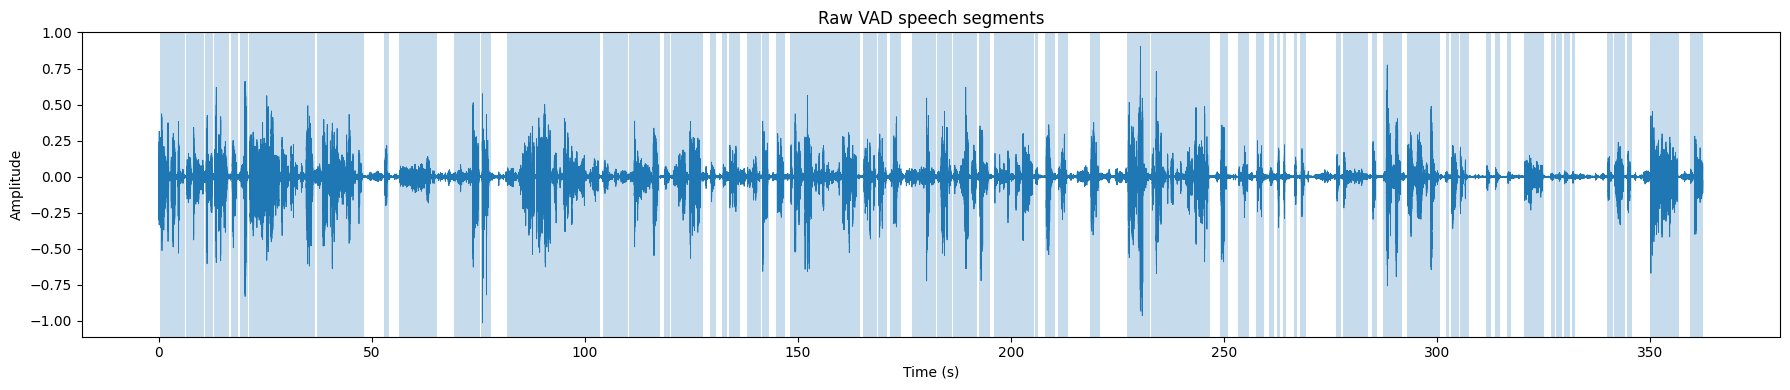

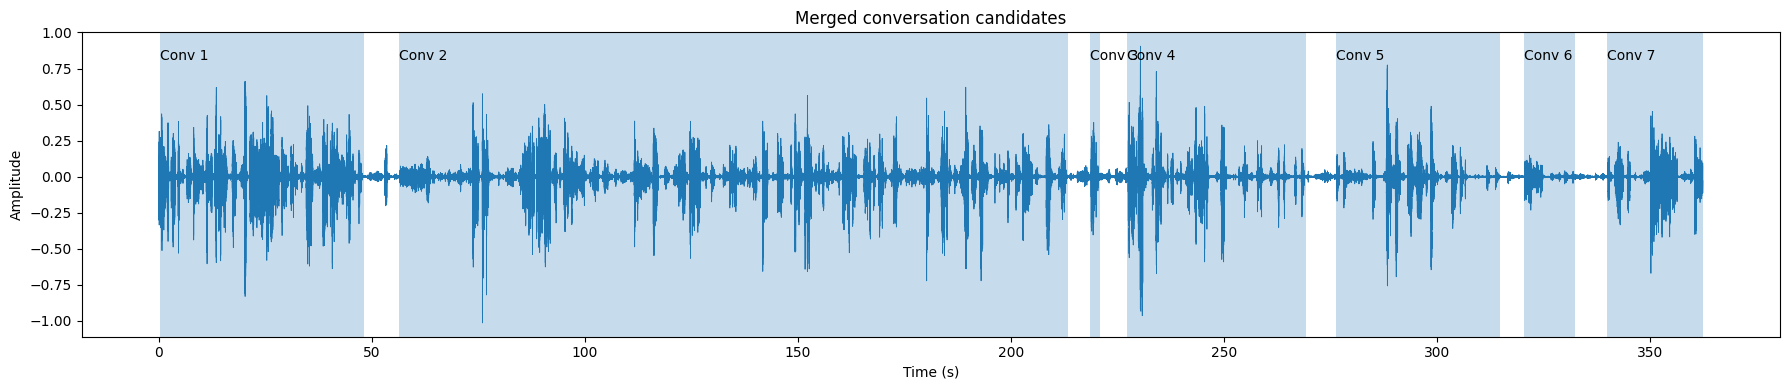

In [9]:
plot_waveform_with_segments(
    result["waveform"],
    result["sample_rate"],
    result["speech_segments"],
    title="Raw VAD speech segments"
)

plot_waveform_with_conversations(
    result["waveform"],
    result["sample_rate"],
    result["conversation_candidates"],
    title="Merged conversation candidates"
)